## Modelling Estonian Energy Supply

Forecasting electricity prices in the Estonian grid is a challenging problem due to two compounding sources of complexity. First, supply-side uncertainty is high, as generation depends heavily on variable renewables such as wind, whose output is inherently difficult to predict. Second, Estonia operates within the interconnected Nordic-Baltic electricity market, meaning prices are strongly influenced by cross-border flows from neighboring bidding zones: Latvia, Lithuania, and Finland. Ignoring these spatial dependencies risks producing systematically biased forecasts.

These characteristics motivate a model that is both temporally aware and spatially structured. We represent the Nordic-Baltic grid as a graph, with bidding zones as nodes and physical cross-border transmission flows as edges, and apply a Spatio-Temporal Graph Neural Network (ST-GNN) ([Hadou et al., 2022](https://doi.org/10.48550/arXiv.2110.02880)). ST-GNNs are well-suited to this setting, as they jointly learn spatial dependencies across graph nodes and temporal dynamics across time steps, offering greater flexibility than univariate time series models. However, this flexibility comes at a cost: ST-GNNs require substantially more data, are harder to interpret, and are sensitive to the quality of the graph structure provided. The model is trained on seven years of hourly data (2019–2025) from the [Elering API](https://dashboard.elering.ee/assets/swagger-ui/index.html), supplemented with weather data from [Open-Meteo API](https://archive-api.open-meteo.com/v1/archive) and actual wind generation from [ENTSO-E API](https://transparency.entsoe.eu).

### Data and features

The Elering API data provided hourly production, renewable production, 
electricity prices, and cross-border import/export flows between Estonia 
and Finland, Latvia, Lithuania, and Russia (the latter disconnected from 
the Baltic grid on February 8, 2025
([ERR News, 2024](https://news.err.ee/1609367879/baltics-to-leave-brell-electricity-grid-at-start-of-february-2025);
[Wikipedia](https://en.wikipedia.org/wiki/Baltic_states_synchronization_with_CESA)).
All data was originally recorded at 15-minute or hourly resolution and 
aligned to a common hourly frequency.

The target variable is Estonian domestic energy production (MW). We 
initially considered "available energy", (defined as domestic production 
adjusted for cross-border flows), as the target, since it represents the 
total energy available for consumption. However, this formulation led to 
poorer model performance, as the input features primarily capture drivers 
of domestic production rather than cross-border flows. The added noise 
from flow dynamics made underlying trends harder to learn. We therefore 
use Estonian domestic energy production (MW) as the target variable, and then considered "available energy" for scenario visualizations.

Input features include production, available energy (production + import − export), renewable production, cross-border flows to Finland and Latvia, electricity prices, 
temperature, wind speed, and actual wind generation. The model uses a 48-hour 
sliding input window (t−48 to t−1) to predict production 24 hours ahead (t+24), 
so all features are strictly historical with no leakage. Explicit 24-hour lags of 
production and available energy are additionally included, extending the model's 
effective lookback to 72 hours and allowing it to directly observe the same hour 
on the previous two days. Weather variables (temperature and wind speed at 10 m) and cyclic calendar 
encodings (hour, day-of-week, month) are also included, alongside actual 
metered wind generation from [ENTSO-E](https://transparency.entsoe.eu), 
which gives the model a direct view of the wind component within total 
production. Finally, grid frequency deviation from 50 Hz is included as 
a measure of real-time supply-demand imbalance across the synchronous grid, ([grid stability signal](https://www.neso.energy/energy-101/electricity-explained/how-do-we-balance-grid/what-frequency)).

No unnecessary lags are applied to current-state measurements such as production or flows, as these reflect the state of the system at forecast time and are fully observable. All of this input data is fetched from the corresponding APIs.
The 24-hour lag is retained only for features where yesterday's value at the same hour carries a predictive signal beyond the current reading.


### Graph structure

The four bidding zones — Estonia (EE), Finland (FI), Latvia (LV), and Lithuania (LT) — form the nodes of the graph (implemented in Supply_wind.py). Edges represent active cross-border interconnections, with Estonia connected to Finland and Latvia, and Latvia connected to Lithuania, illustrated in Figure 1. All edges are bidirectional and weighted by the absolute mean historical flow magnitude on each interconnector, normalised to [0, 1] by dividing by the maximum edge weight prior to training.
Estonia, as the target node, carries the full feature set described above. The neighboring nodes (FI, LV, LT) carry a reduced feature set consisting of their local electricity prices and the cross-border flows directed toward Estonia (zero for (EE, LT) flow), reflecting the information that is physically transmitted across the interconnections. This asymmetry in node features is intentional: Estonia contains substantially more features than its neighbors, as the model is trained to predict Estonian domestic production.

<img src="../figures/Energy_grid.png" width="10%">

**Figure 1: Graph structure of the Nordic-Baltic electricity market.**



The topology reflects both the geographical layout of the region and the 
physical transmission infrastructure: edges correspond to active high-voltage 
interconnections between bidding zones. Estonia has no direct cable connection 
to Lithuania, so no edge is drawn between them. Russia was excluded as a graph 
node due to limited data availability. However, 
the historical cross-border flows between Estonia and Russia are incorporated 
implicitly through the available energy feature of the Estonian node, though 
these flows are effectively zero following the BRELL desynchronization in 
February 2025.

### Sequence construction and splits

We use a sliding window of 48 hours (2 days) as the input sequence, with the model tasked to predict the 24-hour production profile of the following day. This sequence length yielded comparable performance to longer windows of 168 hours (1 week) at substantially lower computational cost.

A chronological holdout strategy was adopted, as this is the appropriate evaluation framework for time series data — random shuffling across folds would introduce temporal leakage by allowing future observations to inform the model during training. The final 20% of the training data constitutes the validation set, and January 2026 is reserved entirely as the test set.

All features and time series were differenced and normalised prior to training. Differencing was applied to address non-stationarity in the production signal, while normalisation constrains the input range across features, mitigating the risk of exploding gradients and promoting stable optimisation dynamics.

### Model architecture

 [Hadou et al. (2022)](https://doi.org/10.48550/arXiv.2110.02880) introduce a Spatio-Temporal Graph Neural Network that 
jointly processes time-varying graph signals by composing graph and time 
convolutional filters into a space-time shift operator, with proven stability 
under both graph and time perturbations. Motivated by this framework, we 
implement (in STGNN.py) a related but distinct architecture: rather than convolutional 
filters, we use graph attention for spatial dependencies and a recurrent 
network for temporal dynamics — a combination better suited to the small, 
irregular topology of the Baltic electricity grid.

The model consists of two components: a spatial module and a temporal module. 
The spatial module applies two successive GATv2 graph attention layers to each 
hourly graph snapshot, with edge attributes encoding the normalised cross-border 
flow magnitudes. Each attention layer uses four attention heads with outputs 
averaged, allowing the model to attend to different aspects of the neighbourhood 
structure simultaneously. Residual connections are added after each attention 
layer to stabilise training and prevent representational collapse in deeper 
networks.

The temporal module operates on the Estonia node exclusively. The Estonian node 
embedding is concatenated with an attention-weighted mean of the three neighbour 
embeddings (FI, LV, LT), where attention weights are computed as a soft alignment 
between the Estonian embedding and each neighbour. Positional embeddings are added 
to make the absolute timestep within the sequence explicit to the model, 
supplementing the GRU's relative ordering with global position information. This 
combined sequence is passed through a two-layer GRU with dropout applied between 
layers. An additional dropout layer is applied to the final hidden state before 
decoding, as PyTorch's GRU dropout does not act on the output of the last layer.

The decoder is a two-layer feed-forward network with LayerNorm applied after the 
first linear layer, followed by ReLU activation and dropout. LayerNorm was 
preferred over BatchNorm for its robustness under distribution shift — a relevant 
concern in energy time series where statistical properties vary across seasons and 
years. The network outputs three quantile estimates: P10, P50, and P90, 
corresponding to a lower bound, median, and upper bound of the predicted 
production. Quantile monotonicity (P10 ≤ P50 ≤ P90) is enforced via a 
differentiable sort operation, ensuring valid intervals without constraining 
the loss function.

The ST-GNN architecture is visualized below:

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


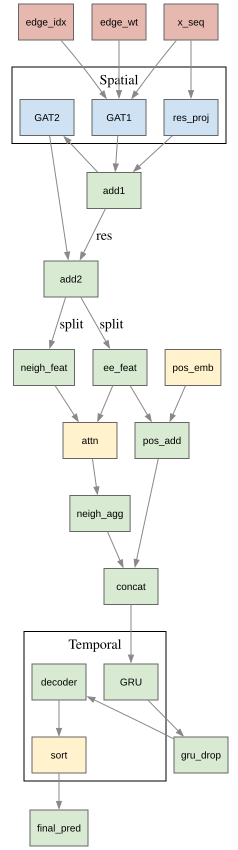

In [1]:
from STGNN import dot_code2
import graphviz, warnings
graph = graphviz.Source(dot_code2)
graph

**Figure 2: ST-GNN Architecture.** 

The model takes a sequence of hourly 
graph snapshots as input (x_seq), where each snapshot contains features 
for all four nodes (EE, FI, LV, LT). 

In the spatial module, two GATv2 attention layers process the graph 
structure using cross-border flow magnitudes as edge weights (edge_wt). 
Residual connections bypass each attention layer and are added to the 
output, helping preserve information across layers.

The node embeddings are then split into the Estonian node (ee_feat) and 
its neighbours (neigh_feat). The neighbour embeddings are aggregated using 
attention weights that reflect how relevant each neighbour is to Estonia 
at each timestep. Positional embeddings are added to the Estonian sequence 
to give the model awareness of where in time each observation falls. The 
two components are then concatenated into a single sequence.

In the temporal module, this combined sequence is passed through a 
two-layer GRU, which captures how the system evolves over the 48-hour 
input window. A dropout layer is applied to the final hidden state before 
the decoder produces three quantile estimates. These are sorted to 
guarantee that P10 ≤ P50 ≤ P90, yielding a valid forecast interval.

### Training

The model was trained for up to 50 epochs using the Adam optimizer with an initial learning rate of $10^{-5}$ and a weight decay of $10^{-2}$ for regularization. The model was optimized using a quantile loss function targeting the 0.1, 0.5, and 0.9 quantiles, producing a point forecast (P50) alongside an 80% prediction interval (P10–P90) that captures 
forecast uncertainty. Gradient norm clipping with a maximum threshold of 1.0 was applied to ensure numerical stability during backpropagation. A ReduceLROnPlateau scheduler halved the learning rate if validation loss failed to improve for eight consecutive epochs, allowing finer weight adjustments as the model approached convergence. Finally, to minimize overfitting, an early stopping mechanism with a patience of 10 epochs was employed, which monitored validation performance and automatically restored the best-performing model weights before terminating of the training process.

### Evaluation

Following the training and validation phase, the model’s generalization capabilities were verified on a hold-out test set covering the January 2026 period. While validation loss was used to guide hyperparameter tuning and early stopping, the test set provides an unbiased assessment of how the model performs on entirely unseen temporal patterns. After generating forecasts in evaluation mode, the predictions were inverse-transformed from their normalized state back to their original units in Megawatts (MW) to allow for a direct comparison with real-world observations.

The point-forecast accuracy was quantified using Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) relative to the 50th percentile (median) prediction. To evaluate the quality of the uncertainty estimation, we calculated the P10-P90 coverage, which measures the proportion of actual observations that fall within the predicted 80% interval. This evaluation framework ensures that the model is not only accurate in its central tendency but also provides statistically reliable bounds for grid load and flow analysis.

### Scenarios

The trained model predicts Estonian domestic production for January 2026. Four scenarios are constructed as post-hoc adjustments to the model output, avoiding out-of-distribution extrapolation. The four scenarios includes: 

- **S1 — Full grid (baseline):** net cross-border flows (imports and exports) are added to the model's production forecast, representing total available energy under the current interconnected grid.
- **S2 — Full isolation:** only domestic production is available, represented directly by the model output without any flow adjustment.
- **S3 — Isolation + Scenario A wind:** simulated wind generation from planned wind farm capacity is added to S2.
- **S4 — Isolation + Scenario B wind:** simulated wind generation from pipeline wind farm capacity is added to S2.
Since the model targets domestic production only, the full-grid scenario 
requires adding observed net cross-border flows to the forecast. Wind 
scenarios add only the incremental generation from new capacity, so that 
existing wind already captured in the model is not double-counted. The 
P10–P90 prediction interval is carried through unchanged across all 
scenarios, as each adjustment shifts all three quantiles equally.

The ST-GNN test and scenario results is illustrated in Figure 3. 

*   **Mean Absolute Error (MAE):** 121 MW
*   **Root Mean Square Error (RMSE):** 161.2 MW
*   **P10-P90 Coverage:** 71.7% (Target: $\ge 80\%$)

<img src="../figures/stgnn_resilience.png" width="100%">

**Figure 3: ST-GNN test results and scenario analysis for January 2026.**

*(Top left)*
 Training and validation quantile loss over 50 epochs, showing 
stable convergence without significant overfitting. 

*(Top right)* P50 
production forecast versus actual production for January 2026, with the 
shaded P10–P90 band indicating the 80% prediction interval (MAE = 121 MW). 

*(Bottom left)* Available energy by scenario across January 2026, where the 
blue shaded area represents the cost of isolation (gap between S1 and S2). 

*(Bottom right)* Mean available energy per scenario with P10–P90 error bars. 
The dashed line indicates typical Estonian consumption (~900 MW), showing 
that isolation (S2) results in a mean deficit, while Scenario B (S4) 
narrowly meets consumption on average.